In [2]:
import os
import json
import pandas as pd

def collect_results_1(experiment_path):
    results = []
    
    # Traverse through experiment folders
    for root, dirs, files in os.walk(experiment_path):
        for file in files:
            if file == 'results.json':
                # Extract relevant details from the folder structure
                folder_name = os.path.basename(root)
                factors = folder_name.split('__')
                
                # Extract batch_size, num_inf_steps, image_size, and cache flag
                batch_size = None
                num_inf_steps = None
                image_size = None
                cache = False
                
                for factor in factors:
                    if "batch_size" in factor:
                        batch_size = int(factor.split('_')[2])
                    elif "num_inf_steps" in factor:
                        num_inf_steps = int(factor.split('_')[3])
                    elif "image_size" in factor:
                        image_size = tuple(map(int, factor.split('_')[2][1:-1].split(',')))
                    elif "cache" in factor:
                        cache = factor.split('_')[1] == 'True'
                
                # Read the results from the JSON file
                with open(os.path.join(root, file)) as f:
                    data = json.load(f)
                
                # Store the data in a structured format (pandas dataframe)
                result = {
                    'batch_size': batch_size,
                    'num_inf_steps': num_inf_steps,
                    'image_size': image_size,
                    'cache': cache,
                    'clip_score': data.get('clip_score', None),
                    'runtime': data.get('runtime (s/b)', None),
                    'clip_score_variance': data.get('clip_score variance', None),
                    'runtime_variance': data.get('runtime variance (s/b)', None)
                }
                results.append(result)
    
    # Convert list of results into a pandas DataFrame
    df = pd.DataFrame(results)
    df['runtime_per_job'] = df['runtime'] / df['batch_size'] if not df.empty else None
    return df

# Define the path to the experiments folder
experiment_path = './diffusion/experiments-1/inference_data/'
df = collect_results_1(experiment_path)
df_clean = df.dropna()
df_clean

,batch_size,num_inf_steps,image_size,cache,clip_score,runtime,clip_score_variance,runtime_variance,runtime_per_job
0,2,15,"(512, 512)",True,31.526132,0.908758,10.074455,0.004495,0.454379
1,2,15,"(256, 256)",False,31.501927,0.761678,12.196641,0.001163,0.380839
2,8,25,"(256, 256)",False,31.294380,3.237638,5.786796,2.724447,0.404705
3,8,15,"(512, 512)",True,31.537064,3.591417,5.090510,0.016586,0.448927
4,2,25,"(256, 256)",True,29.425125,0.559078,12.441721,0.001509,0.279539
5,2,25,"(512, 512)",False,31.728395,3.035082,8.980817,0.000143,1.517541
6,8,15,"(512, 512)",False,31.657593,7.430278,4.442816,0.001278,0.928785
7,8,25,"(256, 256)",True,31.403680,1.460501,4.758898,5.718719,0.182563
8,8,15,"(256, 256)",True,30.855373,0.991855,4.273660,4.721834,0.123982
9,8,25,"(512, 512)",False,31.682307,11.791939,4.416113,0.126155,1.473992


In [3]:
comparison_df = df_clean.groupby('cache').agg(
    mean_clip_score=('clip_score', 'mean'),
    std_clip_score=('clip_score', 'std'),
    mean_runtime=('runtime', 'mean'),
    std_runtime=('runtime', 'std'),
    mean_runtime_per_job=('runtime_per_job', 'mean'),
    std_runtime_per_job=('runtime_per_job', 'std')
).reset_index()

# If you want to see the comparison
comparison_df

,cache,mean_clip_score,std_clip_score,mean_runtime,std_runtime,mean_runtime_per_job,std_runtime_per_job
0,False,31.624622,0.227745,4.091900,3.992131,0.834742,0.499053
1,True,31.006019,0.971541,1.906283,1.754638,0.392027,0.222733


In [65]:
import numpy as np

def calculate_mg1_metrics(inter_arrival_times, service_times, fixed_rho=None):
    """
    Calculate response time and throughput for M/G/1 queue.

    Parameters:
    - inter_arrival_times: List of inter-arrival times
    - service_times: List of service times
    - fixed_rho: Fixed utilization rate (optional)

    Returns:
    - response_time: Average response time (mean time a job spends in the system)
    - throughput: Number of jobs processed per unit time
    - utilization: Utilization rate of the system
    - mean_interarrival_time: Mean inter-arrival time
    """
    if fixed_rho is not None:
        mean_service_time = np.mean(service_times)
        arrival_rate = fixed_rho / mean_service_time
        mean_interarrival_time = 1 / arrival_rate
    else:
        mean_interarrival_time = np.mean(inter_arrival_times)
        arrival_rate = 1 / mean_interarrival_time
        mean_service_time = np.mean(service_times)

    second_moment_service_time = np.mean(service_times ** 2)

    # Utilization factor (rho)
    rho = arrival_rate * mean_service_time

    # compute latency for M/G/1 queueing systems
    response_time = mean_service_time + arrival_rate * second_moment_service_time / (2 * (1 - rho))
    

    # Throughput is simply the arrival rate (lambda)
    throughput = arrival_rate

    return response_time, throughput, rho, mean_interarrival_time

def generate_inter_arrival_times(mean_interarrival_time, num_jobs, distribution="exponential"):
    """
    Generate inter-arrival times based on the chosen distribution.

    Parameters:
    - mean_interarrival_time: Mean inter-arrival time
    - num_jobs: Number of jobs to simulate
    - distribution: Distribution type ("exponential" or "poisson")

    Returns:
    - inter_arrival_times: List of inter-arrival times
    """
    if distribution == "exponential":
        return np.random.exponential(mean_interarrival_time, num_jobs)
    elif distribution == "poisson":
        return np.random.poisson(mean_interarrival_time, num_jobs)
    else:
        raise ValueError("Unsupported distribution type. Use 'exponential' or 'poisson'.")

# Parameters for simulation
num_jobs = len(df_clean)  # Replace df_clean with your dataset
fixed_rho = 0.8
mean_interarrival_time = 0.5

# Separate data based on cache status
cached_jobs = df_clean[df_clean["cache"] == True]
uncached_jobs = df_clean[df_clean["cache"] == False]

# Get service times for cached and uncached jobs
cached_service_times = cached_jobs["runtime_per_job"].values
uncached_service_times = uncached_jobs["runtime_per_job"].values

# Scenario 1: Fixed rho = 0.8
cached_latency_rho, cached_throughput_rho, cached_utilization_rho, cached_mean_interarrival_rho = calculate_mg1_metrics(
    None, cached_service_times, fixed_rho=fixed_rho
)
uncached_latency_rho, uncached_throughput_rho, uncached_utilization_rho, uncached_mean_interarrival_rho = calculate_mg1_metrics(
    None, uncached_service_times, fixed_rho=fixed_rho
)

# Scenario 2: Poisson distribution with mean interarrival time = 1.3
cached_inter_arrival_poisson = generate_inter_arrival_times(mean_interarrival_time, 1000, distribution="poisson")
uncached_inter_arrival_poisson = generate_inter_arrival_times(mean_interarrival_time, 1000, distribution="poisson")

cached_latency_poisson, cached_throughput_poisson, cached_utilization_poisson, _ = calculate_mg1_metrics(
    cached_inter_arrival_poisson, cached_service_times
)
uncached_latency_poisson, uncached_throughput_poisson, uncached_utilization_poisson, _ = calculate_mg1_metrics(
    uncached_inter_arrival_poisson, uncached_service_times
)

# Scenario 3: Exponential distribution with mean interarrival time = 1.3
cached_inter_arrival_exponential = generate_inter_arrival_times(mean_interarrival_time, 1000, distribution="exponential")
uncached_inter_arrival_exponential = generate_inter_arrival_times(mean_interarrival_time, 1000, distribution="exponential")

cached_latency_exponential, cached_throughput_exponential, cached_utilization_exponential, _ = calculate_mg1_metrics(
    cached_inter_arrival_exponential, cached_service_times
)
uncached_latency_exponential, uncached_throughput_exponential, uncached_utilization_exponential, _ = calculate_mg1_metrics(
    uncached_inter_arrival_exponential, uncached_service_times
)

# Compile results into a DataFrame
results = {
    "Scenario": ["Fixed Rho", "Fixed Rho", "Exponential", "Exponential", "Poisson", "Poisson"],
    "System": ["Cached", "Uncached", "Cached", "Uncached", "Cached", "Uncached"],
    "Response Time": [
        cached_latency_rho, uncached_latency_rho,
        cached_latency_exponential, uncached_latency_exponential,
        cached_latency_poisson, uncached_latency_poisson
    ],
    "Throughput": [
        cached_throughput_rho, uncached_throughput_rho,
        cached_throughput_exponential, uncached_throughput_exponential,
        cached_throughput_poisson, uncached_throughput_poisson
    ],
    "Utilization": [
        cached_utilization_rho, uncached_utilization_rho,
        cached_utilization_exponential, uncached_utilization_exponential,
        cached_utilization_poisson, uncached_utilization_poisson
    ]
}

results_df = pd.DataFrame(results)

# Output the DataFrame
results_df

,Scenario,System,Response Time,Throughput,Utilization
0,Fixed Rho,Cached,1.413356,2.040677,0.800000
1,Fixed Rho,Uncached,3.063651,0.958381,0.800000
2,Exponential,Cached,1.292305,1.987236,0.779050
3,Exponential,Uncached,-0.479527,2.079757,1.736059
4,Poisson,Cached,1.413706,2.040816,0.800055
5,Poisson,Uncached,-0.584489,1.972387,1.646433


In [25]:
import numpy as np
import pandas as pd

def simulate_queue(num_jobs, mean_interarrival_time, mean_service_time, 
                   interarrival_dist, service_time_dist):
    """
    Simulates a job queue with given parameters and calculates metrics.
    
    Parameters:
    - num_jobs: Number of jobs to simulate
    - mean_interarrival_time: Mean inter-arrival time
    - mean_service_time: Mean service time
    - interarrival_dist: Distribution for inter-arrival times ('exponential', 'poisson')
    - service_time_dist: Distribution for service times ('exponential', 'poisson')
    
    Returns:
    - response_time: Average response time
    - throughput: Throughput of the system
    - utilization: Utilization of the system
    """
    # Generate inter-arrival times
    if interarrival_dist == "exponential":
        inter_arrival_times = np.random.exponential(mean_interarrival_time, num_jobs)
    elif interarrival_dist == "poisson":
        inter_arrival_times = np.random.poisson(mean_interarrival_time, num_jobs)
    else:
        raise ValueError("Unsupported interarrival distribution")

    # Generate service times
    if service_time_dist == "exponential":
        service_times = np.random.exponential(mean_service_time, num_jobs)
    elif service_time_dist == "poisson":
        service_times = np.random.poisson(mean_service_time, num_jobs)
    elif service_time_dist == "normal":
        service_times = np.random.normal(mean_service_time, num_jobs)
    else:
        raise ValueError("Unsupported service time distribution")
    
    # # Arrival times
    # arrival_times = np.cumsum(inter_arrival_times)
    
    # # Initialize variables
    # start_times = np.zeros(num_jobs)
    # departure_times = np.zeros(num_jobs)
    # response_times = np.zeros(num_jobs)
    
    # # Simulate job processing
    # for i in range(num_jobs):
    #     if i == 0:
    #         start_times[i] = arrival_times[i]
    #     else:
    #         start_times[i] = max(arrival_times[i], departure_times[i - 1])
    #     departure_times[i] = start_times[i] + service_times[i]
    #     response_times[i] = departure_times[i] - arrival_times[i]
    
    # # Calculate metrics
    # total_time = departure_times[-1]  # Total simulation time
    # throughput = num_jobs / total_time
    # utilization = np.sum(service_times) / total_time
    # average_response_time = np.mean(response_times)
    
    # return average_response_time, throughput, utilization
    
    # Calculate metrics using the M/G/1 formula
    response_time, throughput, utilization, _ = calculate_mg1_metrics(
        inter_arrival_times, service_times
    )
    
    return response_time, throughput, utilization

# Parameter combinations
num_jobs_list = [1000, 10000, 100000]
mean_service_time_list = [0.83, 0.39]
service_time_dist_list = ["exponential"]
interarrival_time_dist_list = ["exponential", "poisson"]
mean_interarrival_time_list = [1.3, 0.7]

# Store results
results = []

# Simulate all parameter combinations
for num_jobs in num_jobs_list:
    for mean_service_time in mean_service_time_list:
        for service_time_dist in service_time_dist_list:
            for interarrival_time_dist in interarrival_time_dist_list:
                for mean_interarrival_time in mean_interarrival_time_list:
                    avg_response_time, throughput, utilization = simulate_queue(
                        num_jobs, mean_interarrival_time, mean_service_time, 
                        interarrival_time_dist, service_time_dist
                    )
                    results.append({
                        "Num Jobs": num_jobs,
                        "Mean Service Time": mean_service_time,
                        "Service Time Dist": service_time_dist,
                        "Interarrival Time Dist": interarrival_time_dist,
                        "Mean Interarrival Time": mean_interarrival_time,
                        "Avg Response Time": avg_response_time,
                        "Throughput": throughput,
                        "Utilization": utilization
                    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display results
results_df


,Num Jobs,Mean Service Time,Service Time Dist,Interarrival Time Dist,Mean Interarrival Time,Avg Response Time,Throughput,Utilization
0,1000,0.83,exponential,exponential,1.3,2.618394,0.799741,0.677153
1,1000,0.83,exponential,exponential,0.7,-5.979947,1.436489,1.134474
2,1000,0.83,exponential,poisson,1.3,2.377967,0.778816,0.647379
3,1000,0.83,exponential,poisson,0.7,-3.805521,1.464129,1.210395
4,1000,0.39,exponential,exponential,1.3,0.609852,0.785418,0.323753
5,1000,0.39,exponential,exponential,0.7,1.012447,1.480926,0.600100
6,1000,0.39,exponential,poisson,1.3,0.578603,0.773994,0.308084
7,1000,0.39,exponential,poisson,0.7,0.896108,1.424501,0.565046
8,10000,0.83,exponential,exponential,1.3,2.348105,0.766165,0.645148
9,10000,0.83,exponential,exponential,0.7,-4.256881,1.434197,1.190686


In [16]:
# Filter results_df for Num Jobs = 1000
filtered_results = results_df[
    (results_df["Num Jobs"] == 1000) & (results_df["Mean Interarrival Time"] == 0.5)
]

# Create a pivot table with mean metrics for each combination
final_table = (
    filtered_results.groupby(["Interarrival Time Dist", "Mean Service Time"])
    .mean(numeric_only=True)[["Avg Response Time", "Throughput", "Utilization"]]
    .reset_index()
)

# Adjust "System" values to include the mean service times for Cached and Uncached
final_table["Mean Service Time"] = final_table["Mean Service Time"].replace(
    {0.39: "Cached", 0.83: "Uncached"}
)

# Reorder and rename columns for the final output
final_table = final_table.rename(
    columns={
        "Mean Service Time": "System",
        "Interarrival Time Dist": "Distribution",
        "Response Time": "Response Time",
        "Throughput": "Throughput",
        "Utilization": "Utilization",
    }
)

final_table = pd.DataFrame(final_table)
final_table


,Distribution,System,Avg Response Time,Throughput,Utilization
0,exponential,Cached,1.674576,1.995921,0.767535
1,exponential,Uncached,-1.428181,1.893069,1.544723
2,poisson,Cached,1.776105,2.036660,0.778115
3,poisson,Uncached,-1.182004,2.036660,1.682534


In [18]:
# Filter results_df for Num Jobs = 1000
filtered_results = results_df[
    (results_df["Num Jobs"] == 10000) & (results_df["Mean Interarrival Time"] == 1.3)
]

# Create a pivot table with mean metrics for each combination
final_table = (
    filtered_results.groupby(["Interarrival Time Dist", "Mean Service Time"])
    .mean(numeric_only=True)[["Avg Response Time", "Throughput", "Utilization"]]
    .reset_index()
)

# Adjust "System" values to include the mean service times for Cached and Uncached
final_table["Mean Service Time"] = final_table["Mean Service Time"].replace(
    {0.39: "Cached", 0.83: "Uncached"}
)

# Reorder and rename columns for the final output
final_table = final_table.rename(
    columns={
        "Mean Service Time": "System",
        "Interarrival Time Dist": "Distribution",
        "Response Time": "Response Time",
        "Throughput": "Throughput",
        "Utilization": "Utilization",
    }
)

# Output the final table
final_table = pd.DataFrame(final_table)
final_table

,Distribution,System,Avg Response Time,Throughput,Utilization
0,exponential,Cached,0.547786,0.758242,0.293215
1,exponential,Uncached,2.311941,0.777575,0.642345
2,poisson,Cached,0.546903,0.766401,0.296013
3,poisson,Uncached,2.263171,0.759186,0.634461


In [97]:
# Filter results_df for Num Jobs = 1000
filtered_results = results_df[
    (results_df["Num Jobs"] == 100000) & (results_df["Mean Interarrival Time"] == 0.5)
]

# Create a pivot table with mean metrics for each combination
final_table = (
    filtered_results.groupby(["Interarrival Time Dist", "Mean Service Time"])
    .mean(numeric_only=True)[["Avg Response Time", "Throughput", "Utilization"]]
    .reset_index()
)

# Adjust "System" values to include the mean service times for Cached and Uncached
final_table["Mean Service Time"] = final_table["Mean Service Time"].replace(
    {0.39: "Cached", 0.83: "Uncached"}
)

# Reorder and rename columns for the final output
final_table = final_table.rename(
    columns={
        "Mean Service Time": "System",
        "Interarrival Time Dist": "Distribution",
        "Response Time": "Response Time",
        "Throughput": "Throughput",
        "Utilization": "Utilization",
    }
)

# Output the final table
final_table = pd.DataFrame(final_table)
final_table

,Distribution,System,Avg Response Time,Throughput,Utilization
0,exponential,Cached,2.337471,2.002488,0.781380
1,exponential,Uncached,-1.367500,2.001847,1.659391
2,poisson,Cached,2.231864,1.983675,0.773208
3,poisson,Uncached,-1.369497,1.995849,1.659217


In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Clip Score
model_clip_score = ols('clip_score ~ C(batch_size) * C(num_inf_steps) * C(image_size) * C(cache)', data=df_clean).fit()
anova_table_clip_score = sm.stats.anova_lm(model_clip_score)
conf_int_clip_score = model_clip_score.conf_int(alpha=0.05)

# Runtime
model_runtime = ols('runtime_per_job ~ C(batch_size) * C(num_inf_steps) * C(image_size) * C(cache)', data=df_clean).fit()
anova_table_runtime = sm.stats.anova_lm(model_runtime)
conf_int_runtime = model_runtime.conf_int(alpha=0.05)

anova_df_clip_score = pd.DataFrame(anova_table_clip_score)
anova_df_runtime = pd.DataFrame(anova_table_runtime)
conf_int_clip_score = pd.DataFrame(conf_int_clip_score).round(3)
conf_int_runtime = pd.DataFrame(conf_int_runtime).round(3)

anova_df_clip_score = anova_df_clip_score[['df', 'sum_sq', 'mean_sq', 'F', 'PR(>F)']].round(3)
anova_df_runtime = anova_df_runtime[['df', 'sum_sq', 'mean_sq', 'F', 'PR(>F)']].round(3)

In [83]:
anova_df_clip_score

,df,sum_sq,mean_sq,F,PR(>F)
C(batch_size),1.0,0.016,0.016,0.042,0.840
C(num_inf_steps),1.0,0.328,0.328,0.859,0.368
C(image_size),1.0,5.820,5.820,15.268,0.001
C(cache),1.0,3.061,3.061,8.032,0.012
C(batch_size):C(num_inf_steps),1.0,0.022,0.022,0.058,0.812
C(batch_size):C(image_size),1.0,0.017,0.017,0.044,0.836
C(num_inf_steps):C(image_size),1.0,0.022,0.022,0.058,0.813
C(batch_size):C(cache),1.0,0.125,0.125,0.329,0.574
C(num_inf_steps):C(cache),1.0,0.214,0.214,0.562,0.464
C(image_size):C(cache),1.0,2.252,2.252,5.907,0.027


In [84]:
conf_int_clip_score

,0,1
Intercept,30.573,32.424
C(batch_size)[T.8],-1.490,1.128
C(num_inf_steps)[T.25],-1.245,1.372
"C(image_size)[T.(512, 512)]",-0.835,1.783
C(cache)[T.True],-2.751,-0.133
C(batch_size)[T.8]:C(num_inf_steps)[T.25],-1.755,1.946
"C(batch_size)[T.8]:C(image_size)[T.(512, 512)]",-2.008,1.693
"C(num_inf_steps)[T.25]:C(image_size)[T.(512, 512)]",-2.080,1.621
C(batch_size)[T.8]:C(cache)[T.True],-1.552,2.150
C(num_inf_steps)[T.25]:C(cache)[T.True],-1.535,2.167


In [85]:
anova_df_runtime

,df,sum_sq,mean_sq,F,PR(>F)
C(batch_size),1.0,0.016,0.016,5.356,0.034
C(num_inf_steps),1.0,0.741,0.741,242.517,0.000
C(image_size),1.0,2.935,2.935,961.151,0.000
C(cache),1.0,1.568,1.568,513.421,0.000
C(batch_size):C(num_inf_steps),1.0,0.004,0.004,1.161,0.297
C(batch_size):C(image_size),1.0,0.022,0.022,7.164,0.017
C(num_inf_steps):C(image_size),1.0,0.144,0.144,47.287,0.000
C(batch_size):C(cache),1.0,0.001,0.001,0.227,0.640
C(num_inf_steps):C(cache),1.0,0.117,0.117,38.316,0.000
C(image_size):C(cache),1.0,0.413,0.413,135.278,0.000


In [86]:
conf_int_runtime

,0,1
Intercept,0.296,0.462
C(batch_size)[T.8],-0.273,-0.038
C(num_inf_steps)[T.25],0.099,0.333
"C(image_size)[T.(512, 512)]",0.460,0.694
C(cache)[T.True],-0.313,-0.079
C(batch_size)[T.8]:C(num_inf_steps)[T.25],-0.131,0.200
"C(batch_size)[T.8]:C(image_size)[T.(512, 512)]",-0.038,0.294
"C(num_inf_steps)[T.25]:C(image_size)[T.(512, 512)]",0.178,0.510
C(batch_size)[T.8]:C(cache)[T.True],-0.077,0.254
C(num_inf_steps)[T.25]:C(cache)[T.True],-0.286,0.045


Mean Absolute Error (MAE): 0.025
Mean Squared Error (MSE): 0.002
R-squared (R2): 0.977


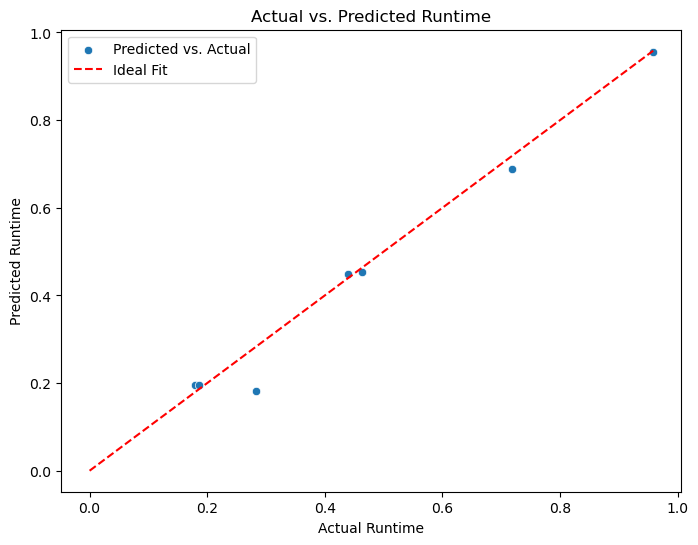

In [77]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42)

model_runtime = ols('runtime_per_job ~ C(batch_size) * C(num_inf_steps) * C(image_size) * C(cache)', data=train_df).fit()

test_df['predicted_runtime'] = model_runtime.predict(test_df)

mae = mean_absolute_error(test_df['runtime_per_job'], test_df['predicted_runtime'])
mse = mean_squared_error(test_df['runtime_per_job'], test_df['predicted_runtime'])
r2 = r2_score(test_df['runtime_per_job'], test_df['predicted_runtime'])

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"R-squared (R2): {r2:.3f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x='runtime_per_job', y='predicted_runtime', data=test_df, label="Predicted vs. Actual")
plt.plot([0, test_df['runtime_per_job'].max()], [0, test_df['runtime_per_job'].max()], color='red', linestyle='--', label="Ideal Fit")
plt.xlabel('Actual Runtime')
plt.ylabel('Predicted Runtime')
plt.title('Actual vs. Predicted Runtime')
plt.legend()
plt.show()


In [39]:
a = np.random.exponential(4,100)
a, np.mean(a)

(array([6.96290339e-01, 5.26410980e-01, 1.58553473e+00, 6.87803270e+00,
        5.00753342e+00, 1.04251425e+01, 2.09940566e+00, 2.25300677e+00,
        5.86884337e-02, 2.88806305e+00, 3.09694571e+00, 7.25953755e+00,
        7.66288662e+00, 4.37789836e+00, 9.95509627e-01, 1.68673879e-01,
        1.54988653e+00, 2.21935491e-01, 7.52874171e-01, 7.60444759e-01,
        2.02936118e+00, 5.33460270e+00, 2.23431578e+00, 1.16571898e+00,
        4.06304983e+00, 6.22371087e+00, 8.34443550e-01, 2.80875069e+00,
        6.65226911e+00, 5.22795640e+00, 2.30267490e+00, 2.47753643e+00,
        6.22170071e+00, 3.25023749e-01, 5.61392645e+00, 1.07531246e-01,
        2.13348113e-01, 4.30013386e+00, 6.68765228e+00, 2.27693042e+01,
        3.52897971e+00, 1.21475702e+00, 2.69682071e+00, 6.49185788e-01,
        5.59505228e+00, 1.97809796e+00, 1.22661598e+00, 2.04560907e+01,
        8.99651210e-01, 1.71843297e+00, 2.00981865e+00, 3.23269921e+00,
        8.86076854e+00, 3.68081190e+00, 6.31681757e+00, 2.218004

In [101]:
import seaborn as sns


a= np.random.poisson(0.5,(5, 10000))
a.mean(axis=1)


array([0.5071, 0.5029, 0.4924, 0.5025, 0.5042])